**Singapore HDB Resale Trend Analysis Using Python**

**Project Overview:**


         


> * This project delivers a data-driven macroeconomic and spatial analysis of Singapore's HDB resale market.
        

>  * This project provides a comprehensive, data-driven   investigation into Singapore's public housing resale market over a transformative nine-year horizon (2017–2026).



> * Utilizing a dataset of over 200,000 plus registered HDB resale transactions, the project maps the market’s evolution across three distinct economic phases(pre-pandemic,post-covid and the recent market stabilization).





    







Project Objective(Problem Statement):
                   



> *   To track town by town price growth trajectories.


> *   To analyse the property valuation over the years.


> *   Analyze the resale price index to quantify.


> *   Evaluate the flat type influence the resale.


> *   To analyse the remaining lease period impact on property value.


> *   To identify how the flat model get imapcted for resale.














           
      




      
      

      








    




**Outcome:**
       


> This analysis concludes the better understanding of singapore HDB resale data through exploratory data analysis and visualization techniques.This project helps to discover the trends and realtionships over the HDB resale data.













**Dataset Information:**

   **Source:**[https://data.gov.sg/datasets?topics=housing&resultId=d_8b84c4ee58e3cfc0ece0d773c8ca6abc]

   
   

**Dataset Column/Feature Description:**
|Column Name| Data Type| Description|
|:---|:---:|:---:|
month | Date |The year and month when the resale transaction was registered (formatted as YYYY-MM).|
town| Text| The specific HDB estate or residential town where the property is located.|
flat_type| Text| The room type configuration of the HDB unit (e.g., number of rooms or executive status).|
block |Text| The specific block number of the HDB building.|
street_name |Text |The official street name where the HDB building is located.|
storey_range |Text |The grouped floor level range where the specific unit is located.|
floor_area_sqm |Numeric| The total internal floor area of the flat, measured in square meters.|
flat_model |Text| The design model or architectural classification of the HDB flat.|
lease_commence_date|  Year| The year the 99-year lease officially began for the building.|
remaining_lease| Text| The remaining duration of the 99-year lease at the time of the transaction (expressed in years and months).|
resale_price| Numeric| The final agreed-upon sale price of the flat in Singapore Dollars (SGD).|

**Initial EDA:**

In [1]:
# Import libraries #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset #
url = "https://raw.githubusercontent.com/amsahana2097/HDB-RESALEDATA/refs/heads/main/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(url)

In [3]:
#Dataset Description(row,column)#
df.shape

(231771, 11)

In [4]:
df.size

2549481

This Dataset contains 231771 rows and 11 columns and 2549481 dara elements.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231771 entries, 0 to 231770
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                231771 non-null  object 
 1   town                 231771 non-null  object 
 2   flat_type            231771 non-null  object 
 3   block                231771 non-null  object 
 4   street_name          231771 non-null  object 
 5   storey_range         231771 non-null  object 
 6   floor_area_sqm       231771 non-null  float64
 7   flat_model           231771 non-null  object 
 8   lease_commence_date  231771 non-null  int64  
 9   remaining_lease      231771 non-null  object 
 10  resale_price         231771 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.5+ MB


In [6]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [7]:
df.tail()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
231766,2026-03,YISHUN,EXECUTIVE,836,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,61 years,995000.0
231767,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.0,Apartment,1987,60 years 10 months,980000.0
231768,2026-04,YISHUN,EXECUTIVE,827,YISHUN ST 81,01 TO 03,145.0,Maisonette,1987,60 years 06 months,960000.0
231769,2026-05,YISHUN,EXECUTIVE,828,YISHUN ST 81,07 TO 09,145.0,Apartment,1988,60 years 09 months,1068888.0
231770,2026-05,YISHUN,MULTI-GENERATION,666,YISHUN AVE 4,04 TO 06,164.0,Multi Generation,1987,60 years 08 months,1120000.0


In [8]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price'],
      dtype='object')

This shows all the column names.

In [9]:
df.select_dtypes(include='number').columns

Index(['floor_area_sqm', 'lease_commence_date', 'resale_price'], dtype='object')

This helps to identify the all number columns.

In [10]:
df.select_dtypes(include='object').columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'flat_model', 'remaining_lease'],
      dtype='object')

This is used  to identify the all object columns.

In [11]:
df.isnull().sum()

,0
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0


There is no null values found.

In [12]:
df.duplicated().sum()

np.int64(314)

There is no duplicate records.

In [15]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of           month        town         flat_type block        street_name  \
0       2017-01  ANG MO KIO            2 ROOM   406  ANG MO KIO AVE 10   
1       2017-01  ANG MO KIO            3 ROOM   108   ANG MO KIO AVE 4   
2       2017-01  ANG MO KIO            3 ROOM   602   ANG MO KIO AVE 5   
3       2017-01  ANG MO KIO            3 ROOM   465  ANG MO KIO AVE 10   
4       2017-01  ANG MO KIO            3 ROOM   601   ANG MO KIO AVE 5   
...         ...         ...               ...   ...                ...   
231766  2026-03      YISHUN         EXECUTIVE   836       YISHUN ST 81   
231767  2026-03      YISHUN         EXECUTIVE   877       YISHUN ST 81   
231768  2026-04      YISHUN         EXECUTIVE   827       YISHUN ST 81   
231769  2026-05      YISHUN         EXECUTIVE   828       YISHUN ST 81   
231770  2026-05      YISHUN  MULTI-GENERATION   666       YISHUN AVE 4   

       storey_range  floor_area_sqm        flat_model  lease_commence_date  \
0          10 TO 12            44.0          Improved                 1979   
1          01 TO 03            67.0    New Generation                 1978   
2          01 TO 03            67.0    New Generation                 1980   
3          04 TO 06            68.0    New Generation                 1980   
4          01 TO 03            67.0    New Generation                 1980   
...             ...             ...               ...                  ...   
231766     10 TO 12           146.0        Maisonette                 1988   
231767     07 TO 09           142.0         Apartment                 1987   
231768     01 TO 03           145.0        Maisonette                 1987   
231769     07 TO 09           145.0         Apartment                 1988   
231770     04 TO 06           164.0  Multi Generation                 1987   

           remaining_lease  resale_price  
0       61 years 04 months      232000.0  
1       60 years 07 months      250000.0  
2       62 years 05 months      262000.0  
3        62 years 01 month      265000.0  
4       62 years 05 months      265000.0  
...                    ...           ...  
231766            61 years      995000.0  
231767  60 years 10 months      980000.0  
231768  60 years 06 months      960000.0  
231769  60 years 09 months     1068888.0  
231770  60 years 08 months     1120000.0  

[231771 rows x 11 columns]>

In [ ]:
df.describe().round(2)

,floor_area_sqm,lease_commence_date,resale_price
count,231771.00,231771.00,231771.00
mean,96.70,1996.53,530076.88
std,24.02,14.35,189625.61
min,31.00,1966.00,140000.00
25%,81.00,1985.00,390000.00
50%,93.00,1997.00,500000.00
75%,112.00,2012.00,637944.00
max,366.70,2022.00,1728000.00


Insights for summary statistics:

                 

*   The average flat price stands at $530,076.88, while the median sits at $500,000.00. The fact that the mean is higher than the median shows that the price distribution is right-skewed, pulled upward by luxury transactions.
*  75% of all transactions took place at or below $637,944.00. However, $1,728,000.00. This massive gap between the 3rd quartile and the max price highlights a small, elite tier of ultra-premium resale properties
* The mean floor area is 96.70 sqm, and the median (50%) is 93.00 sqm. This strongly indicates that the inventory is heavily dominated by standard 4-room HDB flats (which typically hover around 90–95 sqm).
*  While 75% of the properties are 112.00 sqm or smaller (standard 5-room flat territory), the maximum value stretches to an extreme 366.70 sqm. This points to the presence of rare, massive housing types like adjoined jumbo flats or HDB terrace houses.



                    

In [ ]:
df.describe(include=object)

,month,town,flat_type,block,street_name,storey_range,flat_model,remaining_lease
count,231771,231771,231771,231771,231771,231771,231771,231771
unique,113,26,7,2762,577,17,21,698
top,2024-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,Model A,94 years 10 months
freq,3036,18814,98356,699,3287,53148,83223,1921


Insight for categorical columns:

                

*   The most active single month in this slice was July 2024 (2024-07) with 3,036 sales.
*   The town column shows 26 unique values. Since there are exactly 26 distinct HDB towns/estates in Singapore,SENGKANG is the most frequently occurring town with 18,814 transactions. This makes total sense structurally, as Sengkang is one of the largest and most densely packed high-rise young estates, generating continuous transaction volume.
*  Out of 7 unique flat types, the 4 ROOM flat is by far the most popular, appearing 98,356 times. This means nearly 42.4% of the entire dataset consists of 4-room units, cementing it as the baseline standard for the average household.
*  Block 2 Dominates, There are 2,762 unique block numbers, and Block 2 is the most common, appearing 699 times.
*  Out of 577 unique street names, YISHUN RING ROAD appears the most frequently with 3,287 transactions.
*  Out of 17 unique storey ranges, the 04 TO 06 storey bracket is the most frequent (53,148 transactions).
*  Model A dominates the market with 83,223 occurrences (roughly 36% of the data).
*  Remaining lease has 698 unique text variations, and the most frequent value is "94 years 10 months" (1,921 occurrences).



                  

**Creating new column:**
            
          *  creating new column named price_per_sqm,by dividing resale_price by floor_area_sqm.
          *  This is used to find out which towns in singapore are truly the most expensive


In [ ]:
df["price_per_sqm"]=df["resale_price"]/df["floor_area_sqm"]

**Data Cleaning and Pre Processing:**

The Dataset contains no missing values and duplicate records.

In [ ]:
# Convert integer years to datetime format specifying the year format '%Y'
df['lease_commence_date'] = pd.to_datetime(df['lease_commence_date'], format='%Y')

In [ ]:
df['lease_commence_date'].dtype

dtype('<M8[ns]')

In [ ]:
#Renaming the column names:
df=df.rename(columns={'resale_price':'resale_price_sgd',
                    'month':'Transaction_monthyear'})

In [ ]:
#Extracting numeric columns:
num_col=df.select_dtypes(include='number')
num_col.head(3)

,floor_area_sqm,resale_price_sgd,price_per_sqm
0,44.0,232000.0,5272.727273
1,67.0,250000.0,3731.343284
2,67.0,262000.0,3910.447761


In [ ]:
#Checking Skewness:
num_col.skew()

,0
floor_area_sqm,0.254912
resale_price_sgd,0.964953
price_per_sqm,1.309572


The floor area sqm have low skewness and resale price have moderate skewness.

In [ ]:
#Checking kurtosis:
num_col.kurt()

,0
floor_area_sqm,0.006001
resale_price_sgd,1.258526
price_per_sqm,2.563968


The floor area sqm has 0 kurtosis represents perfectly normal distributions and resale price has 1.25 kurtosis indicates higher probability of extreme outliers or extreme values.

**EDA and Visualization:**

In [ ]:
df.columns

Index(['Transaction_monthyear', 'town', 'flat_type', 'block', 'street_name',
       'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price_sgd', 'price_per_sqm'],
      dtype='object')

In [ ]:
num_col

,floor_area_sqm,resale_price_sgd,price_per_sqm
0,44.0,232000.0,5272.727273
1,67.0,250000.0,3731.343284
2,67.0,262000.0,3910.447761
3,68.0,265000.0,3897.058824
4,67.0,265000.0,3955.223881
...,...,...,...
231766,146.0,995000.0,6815.068493
231767,142.0,980000.0,6901.408451
231768,145.0,960000.0,6620.689655
231769,145.0,1068888.0,7371.641379


In [ ]:
df['town'].value_counts()

,count
town,
SENGKANG,18814
PUNGGOL,16775
WOODLANDS,16502
TAMPINES,15916
YISHUN,15753
JURONG WEST,15275
BEDOK,12040
HOUGANG,11693
CHOA CHU KANG,10429


In [ ]:
df['flat_model'].value_counts()

,count
flat_model,
Model A,83223
Improved,56593
New Generation,28271
Premium Apartment,25447
Simplified,8862
Apartment,8288
Maisonette,6335
Standard,6176
DBSS,3697


In [ ]:
df['flat_type'].value_counts()

,count
flat_type,
4 ROOM,98356
5 ROOM,56722
3 ROOM,55212
EXECUTIVE,16523
2 ROOM,4787
MULTI-GENERATION,86
1 ROOM,85


**Remove Duplicates:**

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
231766,False
231767,False
231768,False
231769,False


**Visualization:**

**HDB Resale prices evolved from 2017 to 2026 using line chart:**

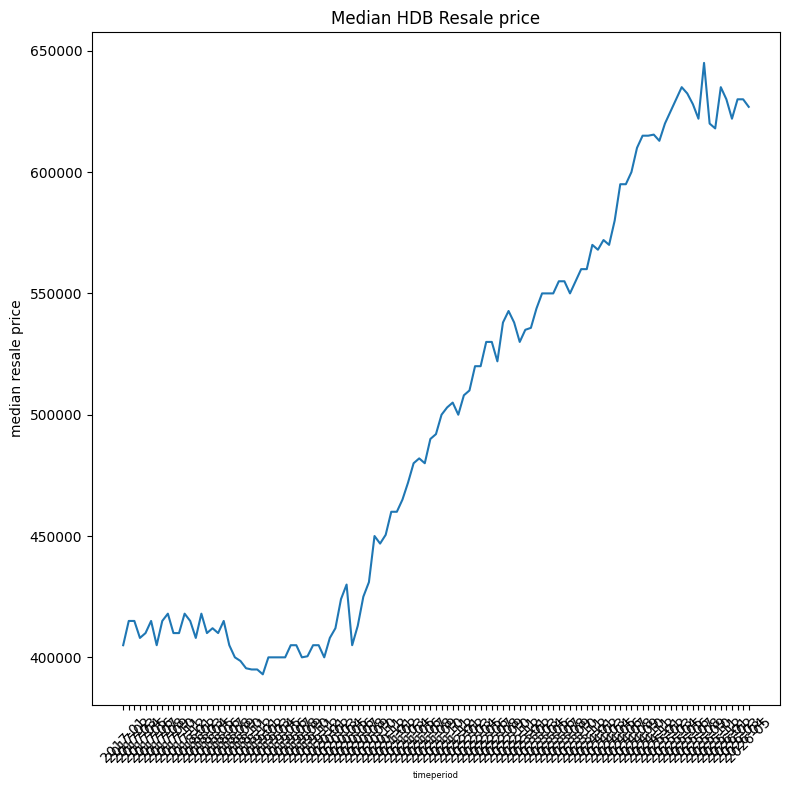

In [ ]:
plt.figure(figsize=(8,8))
trend_df=df.groupby('Transaction_monthyear')['resale_price_sgd'].median().reset_index()
sns.lineplot(data=trend_df,x='Transaction_monthyear',y='resale_price_sgd')
plt.title("Median HDB Resale price")
plt.xlabel("timeperiod",fontsize=6)
plt.ylabel("median resale price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




*   At the start of the timeline, the median resale price remains incredibly flat, hovering consistently between the $400,000 to $420,000 range.
*  Starting in mid-to-late 2020, the line breaks its plateau and enters a sharp, aggressive upward trajectory, climbing steadily without a major correction until it clears the $600,000.
*   At the end of the timeline , the steep climb begins to face minor resistance, showing a slight leveling off at its highest peak.




**Price Distribution using Histogram:**

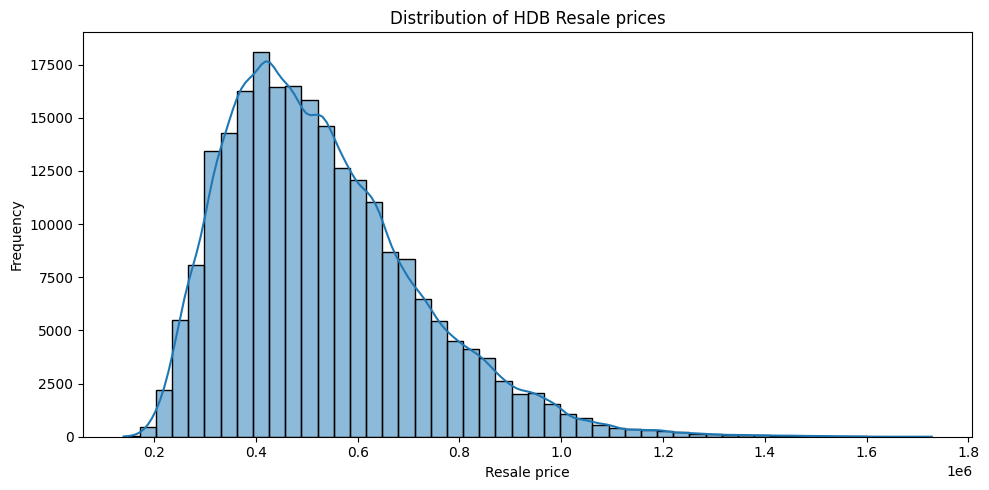

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x="resale_price_sgd",kde=True,bins=50)
median_price=df["resale_price_sgd"].median()
plt.title("Distribution of HDB Resale prices")
plt.xlabel("Resale price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



*   It climbs rapidly on the left, peaks early between $400,000 and $500,000 (0.4 and 0.5), and then trails off slowly into a long, thin right tail stretching all the way past $1,200,000+.




**Comparison of property values across different Towns using bar chart:**

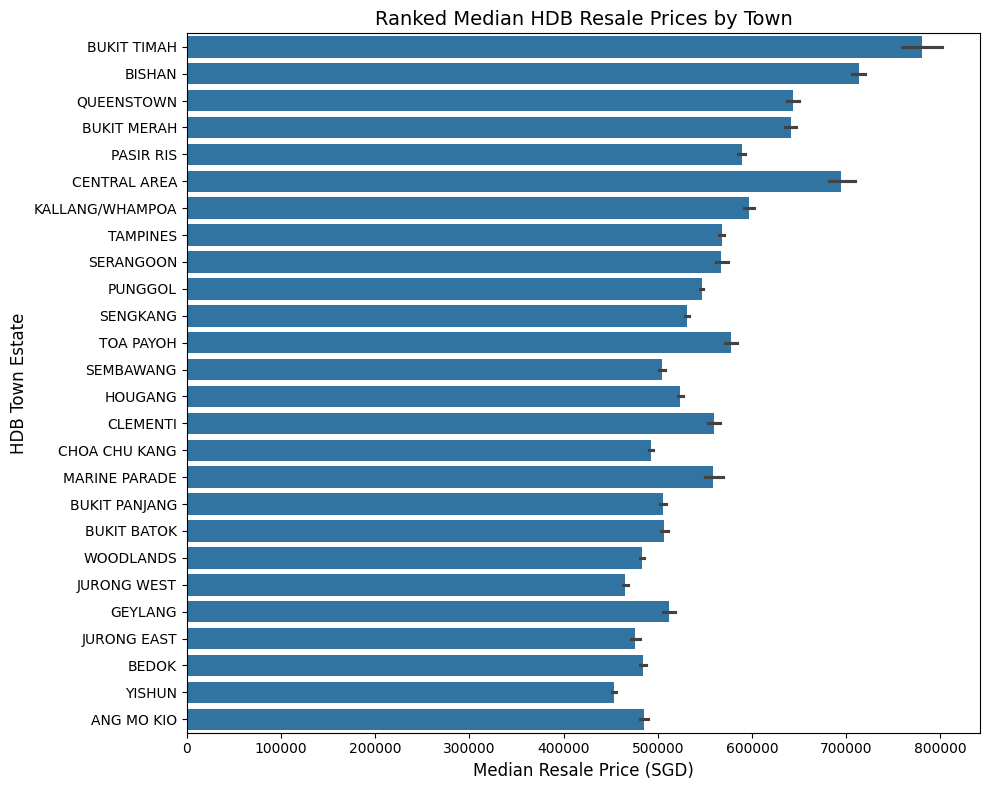

In [ ]:
plt.figure(figsize=(10, 8))

towns = df.groupby('town')['resale_price_sgd'].median().sort_values(ascending=False).index

sns.barplot(data=df, y='town', x='resale_price_sgd', order=towns)
plt.title('Ranked Median HDB Resale Prices by Town', fontsize=14)
plt.xlabel('Median Resale Price (SGD)', fontsize=12)
plt.ylabel('HDB Town Estate', fontsize=12)
plt.tight_layout()
plt.show()



*   The heavy premium buyers place on central proximity, prestige, and top-tier schooling districts. Even though HDB flats are public housing, a prime location like Bukit Timah or Bishan drives median transaction costs significantly higher than suburban equivalents, creeping closer toward the $700,000+ median baseline.

*   Towns like Pasir Ris, Tampines, Clementi, and Hougang populate the middle ground, hovering stably around the $450,000  to $550,000 zone.

*  Towns like Yishun, Woodlands, and Jurong West cluster toward the lower end of the ranking spectrum, with median pricing sitting below $500,000.



**Analysing space efficiency impact using scatter plot with regression:**

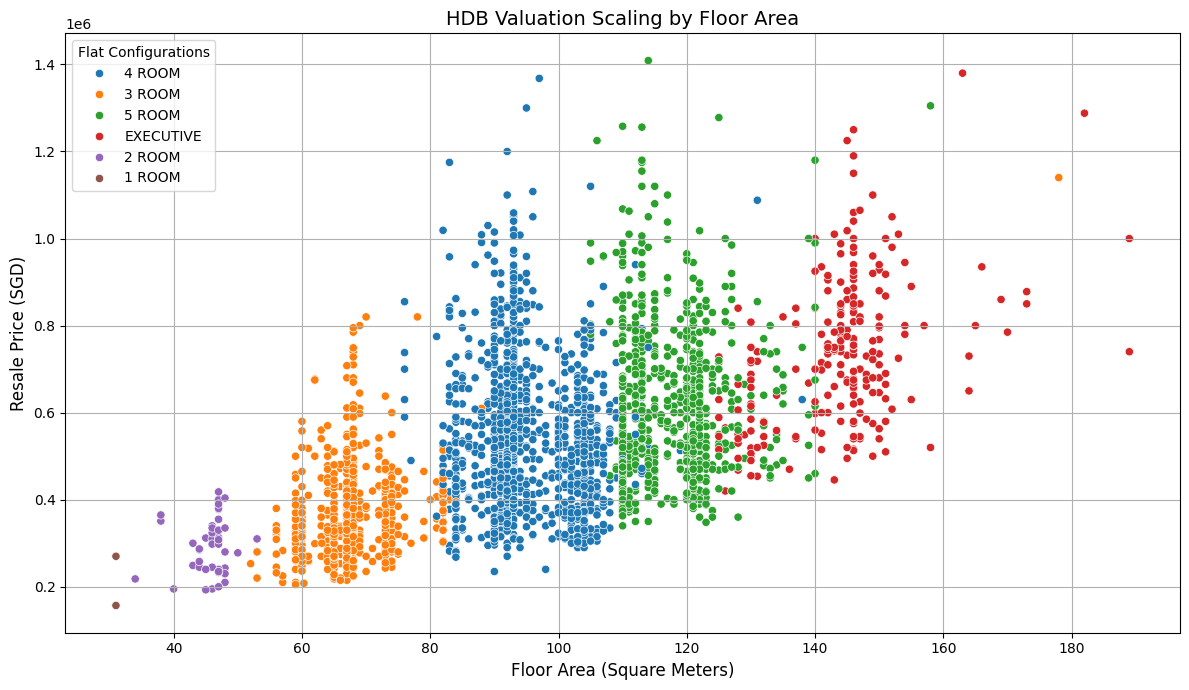

In [ ]:
plt.figure(figsize=(12, 7))
# Take a random sample of 3,000 rows so the scatter plot was easy to analyse.
df_sample = df.sample(3000, random_state=42)

sns.scatterplot(data=df_sample, x='floor_area_sqm', y='resale_price_sgd', hue='flat_type')
plt.title('HDB Valuation Scaling by Floor Area', fontsize=14)
plt.xlabel('Floor Area (Square Meters)', fontsize=12)
plt.ylabel('Resale Price (SGD)', fontsize=12)
plt.legend(title='Flat Configurations')
plt.grid(True)
plt.tight_layout()
plt.show()



*   2-room units stay under 50 sqm, 3-room units group between 60–70 sqm, and  4-room units cluster heavily around 90–100 sqm.

*   Look at the  4-room cluster (90 sqm) or  5-room cluster (110 sqm). For the exact same floor area, the price doesn't stay flat,it stretches vertically all the way from $300,000 to over $1,200,000+ (0.3 to 1.2).

*  Executive flats are significantly larger (130 to 160+ sqm), yet their vertical heights do not exceed the peak prices of smaller 4-room and 5-room flats.



**Pricing impact storey range using count plot:**

/tmp/ipykernel_2040/3486947376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='storey_range', y='resale_price_sgd', order=storey_order, palette='flare', errorbar=None)


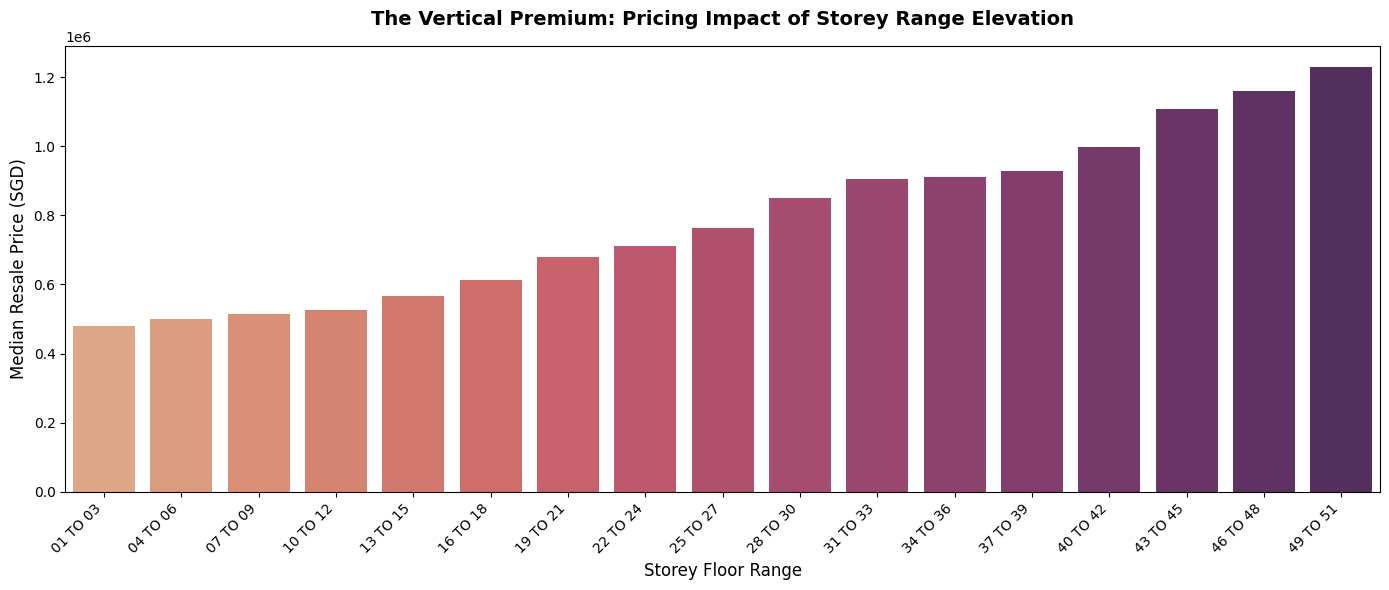

In [ ]:
plt.figure(figsize=(14, 6))
# Sort storey ranges from ground levels upward
storey_order = sorted(df['storey_range'].unique())

sns.barplot(data=df, x='storey_range', y='resale_price_sgd', order=storey_order, palette='flare', errorbar=None)
plt.title('The Vertical Premium: Pricing Impact of Storey Range Elevation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Storey Floor Range', fontsize=12)
plt.ylabel('Median Resale Price (SGD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



*   Starting at ground level (01 TO 03) and moving to the highest peaks (49 TO 51)—the median resale price continuously rises without any dips.
*   This proves that floor height acts as a major premium multiplier in Singapore's public housing sector. Buyers are systematically willing to pay a progressive surplus for higher units



**Correlation Heatmap:**

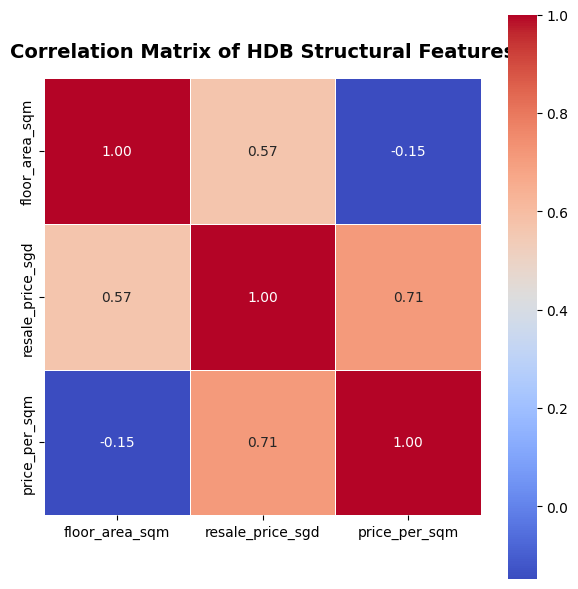

In [ ]:
plt.figure(figsize=(6, 6))
correlation_matrix = num_col.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of HDB Structural Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



*   The correlation between physical size(floor area sqm) and the final transaction price(resale price sgd) is a moderate positive relationship (0.57).
*   The correlation between resale price and price per sqm shows a strong positive correlation value of 0.71.
*   There is a slight negative (inverse) correlation of -0.15 between the raw size (floor area sqm)of the flat and its price-per-square-meter rate.



**Distribution of flat type using pie chart:**

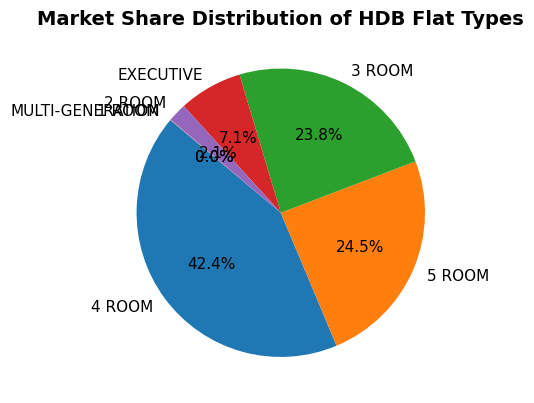

In [ ]:
plt.figure(figsize=(5,5))
flat_counts = df['flat_type'].value_counts()

plt.pie(
    flat_counts,
    labels=flat_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11})

plt.title('Market Share Distribution of HDB Flat Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



*   4-ROOM flats command the high share of the resale market at 42.4%.
*   5-ROOM flats (24.5%) and 3-ROOM flats (23.8%) hold nearly identical, neck-and-neck slices of the remaining market.
*   Executive flats account for a minor 7.1%, while 2-ROOM, 1-ROOM, and MULTI-GENERATION units sit bundled together at tiny fractions (such as 2.1% ).



**Distribution of HDB transaction using flat model**

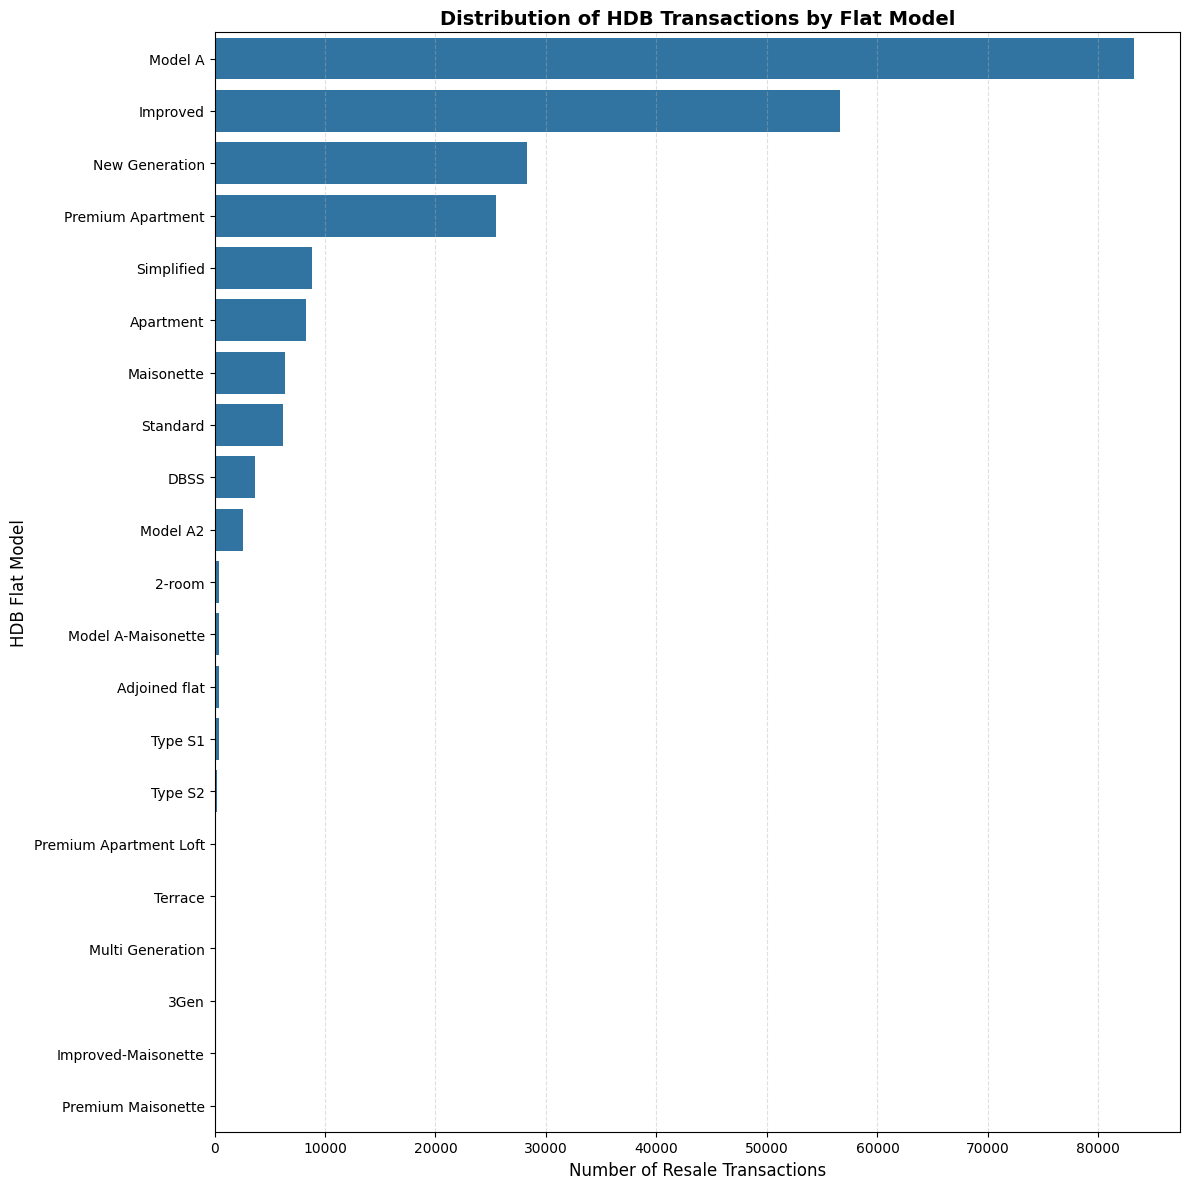

In [ ]:

plt.figure(figsize=(12,12))

model_order = df['flat_model'].value_counts().index

sns.countplot(
    data=df,
    y='flat_model',
    order=model_order)

plt.title('Distribution of HDB Transactions by Flat Model', fontsize=14, fontweight='bold')
plt.xlabel('Number of Resale Transactions', fontsize=12)
plt.ylabel('HDB Flat Model', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



*   Model A and Improved models capture a massive, overwhelming majority of all resale transactions in Singapore, followed by New Generation and Premium Apartments.
*   Models like Maisonette and DBSS look minor on the main chart, while configurations like Type S1, Type S2, Terrace, and Premium Apartment Loft completely flatline near zero at the bottom.
*   Terrace flats (landed public housing) are extremely rare remnants from the pre-HDB SIT era.



**Download cleaned data for dashboard creation using Power BI:**

In [ ]:
# Save Cleaned Data with out Row index column.
df.to_csv("Singapore_HDB_resale_price_analysis_cleaned_dataset.csv",index=False)

In [ ]:
from google.colab import files
files.download("Singapore_HDB_resale_price_analysis_cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Dashboard**

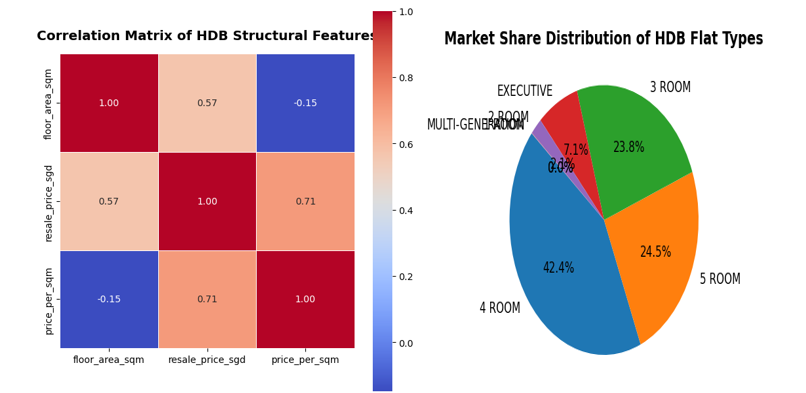

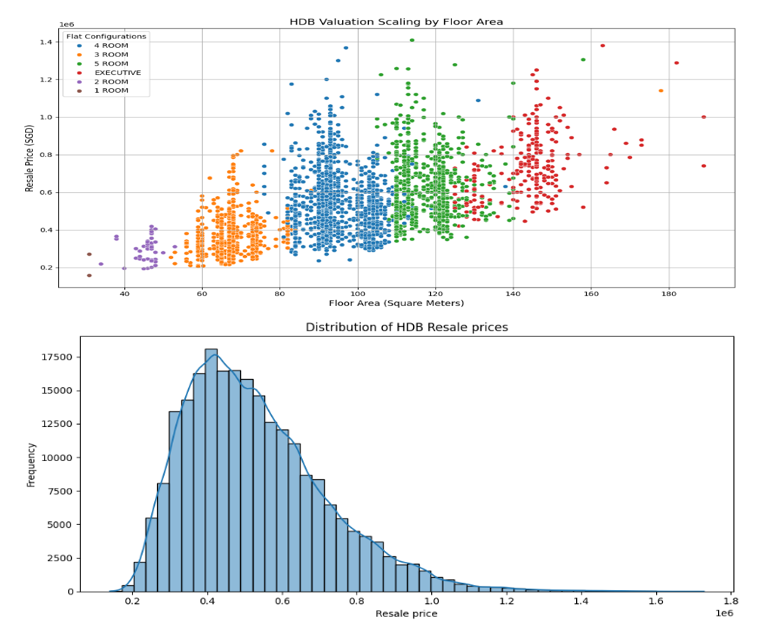

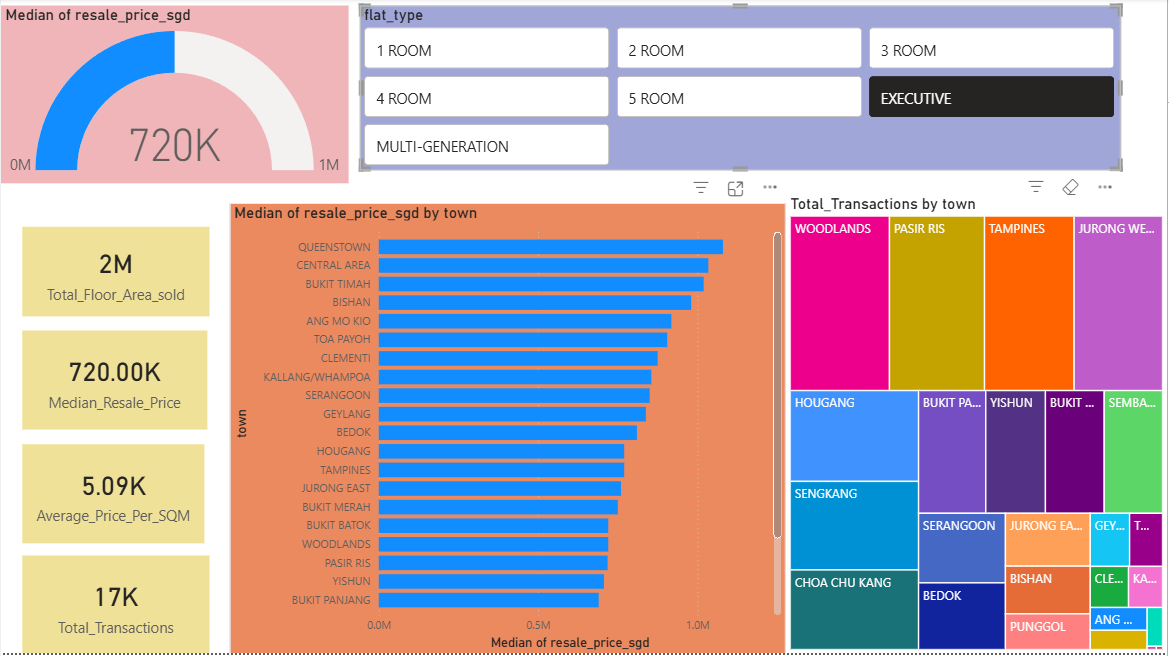

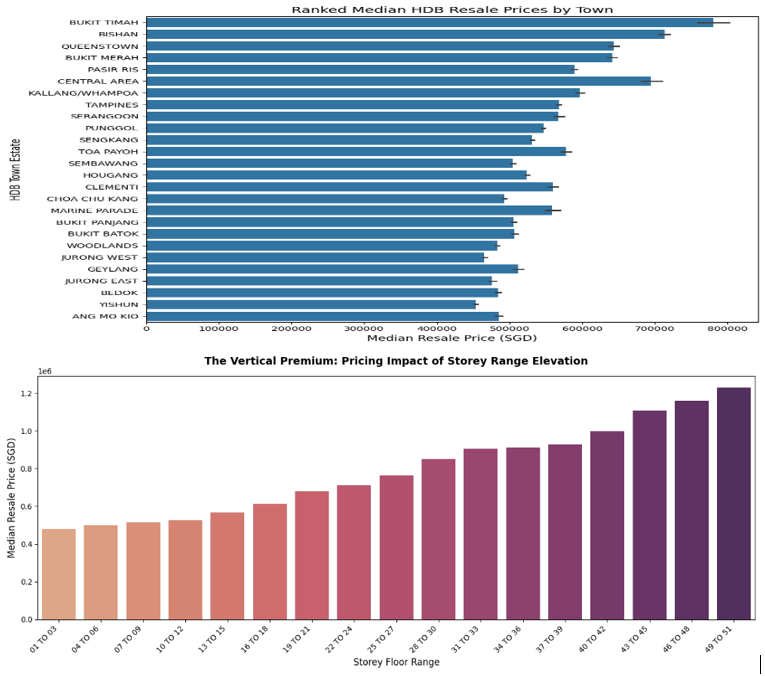

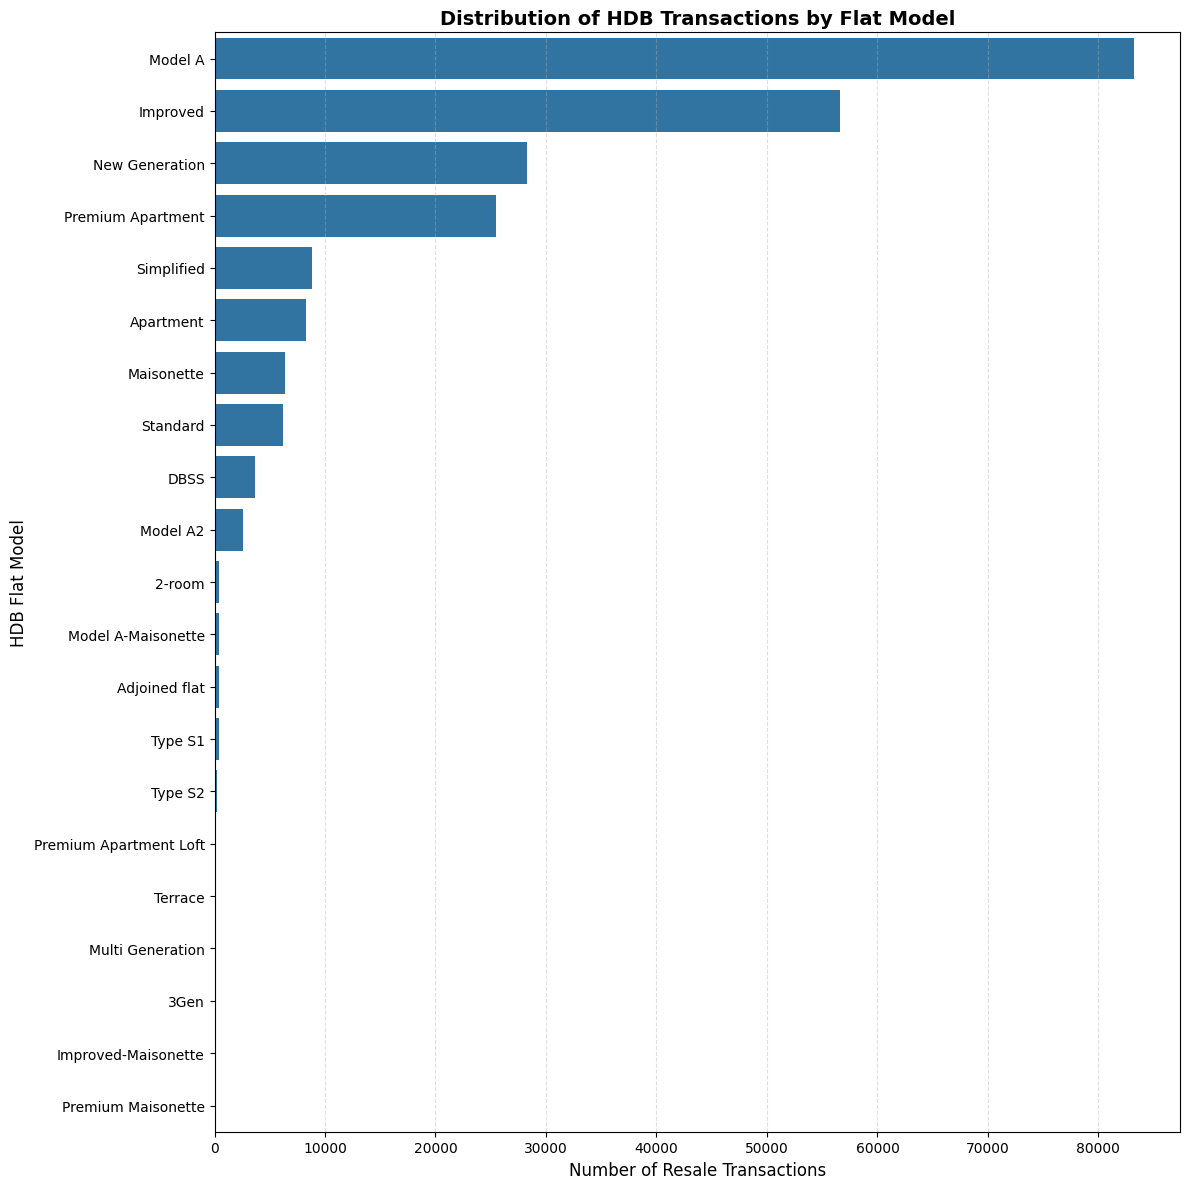

**Documentation Link:**

https://drive.google.com/drive/folders/1gFScoLwWvA4qY0Msqn5Ne91TvQmE0xjX?usp=sharing

**Insights:**



*   HDB resale prices clearly breakouts the profound impact of the pandemic on real estate.
*   The vast majority ofHDB flat transactions occurs affpordable,entry to mid tier price points.However the market has significant premium tier pulling the average upward.
*   premium buyers place on central proximity, prestige, and top-tier schooling districts. Even though HDB flats are public housing, a prime location like Bukit Timah or Bishan drives median transaction costs significantly higher than suburban equivalents.
*  It demonstrates that physical size is not the main driver of high-end property valuation in Singapore, location is. A 90 sqm 4-room flat in a non-mature, far-flung estate sits at the lower end of that vertical line, while an identical 90 sqm 4-room flat located in a prime central area (like Dawson or Queenstown) shoots up to the top of the line. Location premiums completely override raw square footage.
*  The floor height acts as a major premium multiplier in Singapore's public housing sector. Buyers are systematically willing to pay a progressive surplus for higher units. The premium is driven by three main value factors: better panoramic views, reduced road and street-level noise, and superior ventilation/natural light.
*   4-room units are the definitive "standard baseline" of Singaporean public housing.
*   Flats built in the late 1970s, 1980s, and 1990s were heavily dominated by "Model A" and "Improved" architectural blueprints. Because these units represent the primary housing supply ever built across major heartland mega-towns, they form the bedrock liquidity of today's resale market



**Conclusion:**

              

*   This Singapore HDB Resale Trend Analysis project successfully bridges raw historical property records with interactive business intelligence.
             
*   The Singapore public housing market is no longer a uniform utility—it behaves like a mature, competitive asset class. While suburban towns like Woodlands and Sengkang ensure foundational market volume and baseline affordability, a hyper-competitive layer exists where premium location models (like DBSS or high-storey central units) behave like luxury assets.





             
